In [1]:
# Si fuese necesario ejecutar esta celda
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce

In [3]:
# Carga de datos
try:
    movies = pd.read_csv('/content/drive/MyDrive/Archivos .csv/movies_metadata.csv', low_memory=False)
    credits = pd.read_csv('/content/drive/MyDrive/Archivos .csv/credits.csv')
    cpi = pd.read_csv('/content/drive/MyDrive/Archivos .csv/CPI.csv')
    print("Archivos cargados correctamente.")
except FileNotFoundError:
    print("Error: Asegúrate de subir los archivos csv.")

Archivos cargados correctamente.


### Limpieza y Fusión de Tablas
1.  Convertimos la columna `id` a número para evitar errores.
2.  Unimos (`merge`) la tabla de películas con la de créditos usando el `id` como clave común.
3.  Seleccionamos solo las columnas útiles para el proyecto.

In [4]:
# Limpieza Básica
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies.dropna(subset=['id'], inplace=True)
movies['id'] = movies['id'].astype(int)
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce').fillna(0)
credits.rename(columns={'movie_id': 'id'}, inplace=True)

# Fusión
df = pd.merge(movies, credits, on='id', how='inner')

### Definición de Funciones de Extracción
Como los datos de `crew` (equipo), `cast` (actores) y `genres` vienen en formato de texto complejo (JSON), definimos funciones auxiliares para:
* `get_director`: Buscar quién tiene el trabajo de "Director".
* `get_top_3_items`: Extraer los 3 primeros nombres de una lista (sirve para actores y géneros).

Y al final aplicamos las funciones anteriores para crear nuevas columnas limpias.

In [5]:
def get_director(crew_json):
    """Devuelve el nombre del director o 'Unknown'."""
    if pd.isna(crew_json): return 'Unknown'
    try:
        data = ast.literal_eval(crew_json)
        for member in data:
            if member['job'] == 'Director':
                return member['name']
        return 'Unknown'
    except: return 'Unknown'

def get_top_3_items(json_string):
    """
    Sirve tanto para ACTORES como GÉNEROS.
    Devuelve una lista con los 3 primeros nombres encontrados.
    """
    items = ['Unknown', 'Unknown', 'Unknown']
    if pd.isna(json_string): return items
    try:
        data = ast.literal_eval(json_string)
        # Extraemos los 3 primeros nombres si existen
        for i in range(min(len(data), 3)):
            items[i] = data[i]['name']
        return items
    except: return items

# Director
df['director'] = df['crew'].apply(get_director)

# Top 3 Actores
temp_actors = df['cast'].apply(lambda x: pd.Series(get_top_3_items(x)))
df[['actor_1', 'actor_2', 'actor_3']] = temp_actors

# Top 3 Géneros
temp_genres = df['genres'].apply(lambda x: pd.Series(get_top_3_items(x)))
df[['genre_1', 'genre_2', 'genre_3']] = temp_genres

print("Extracción completada:")
print(df[['title', 'genre_1', 'genre_2', 'genre_3', 'actor_1']].head())

Extracción completada:
                         title    genre_1  genre_2  genre_3          actor_1
0                    Toy Story  Animation   Comedy   Family        Tom Hanks
1                      Jumanji  Adventure  Fantasy   Family   Robin Williams
2             Grumpier Old Men    Romance   Comedy  Unknown   Walter Matthau
3            Waiting to Exhale     Comedy    Drama  Romance  Whitney Houston
4  Father of the Bride Part II     Comedy  Unknown  Unknown     Steve Martin


### Filtrado y Cálculo del Objetivo (Target)
1.  **Filtros:** Nos quedamos solo con películas de presupuesto > 100k y de habla inglesa/americanas.
2.  **Media Bayesiana:** Calculamos el `weighted_rating`. Esto equilibra la nota media (`vote_average`) con la cantidad de votos (`vote_count`) para que sea una métrica más justa. Esta será la variable que intentaremos predecir.

In [6]:
# Filtros
df_filtrado = df[
    (df['budget'] > 100000.0) &
    ((df['original_language'] == 'en') | (df['production_countries'].str.contains('US', na=False)))
].copy()

### Ajuste de Inflación (CPI)
El dinero no vale lo mismo hoy que en 1990.
En esta celda usamos el archivo del IPC (`CPI.csv`) para actualizar el presupuesto (`budget`) de cada película al valor del año más reciente. Esto hace que los presupuestos sean comparables entre sí.

In [7]:
# Media Bayesiana (Target)
v = df_filtrado['vote_count']
R = df_filtrado['vote_average']
m = df_filtrado['vote_average'].mean()
C = df_filtrado['vote_count'].median()
df_filtrado['weighted_rating'] = ((v * R) + (m * C)) / (v + C)

# Preparamos los datos del IPC (CPI)
# Aseguramos que los nombres de columnas sean correctos y el año sea numérico
cpi.columns = ['Year', 'CPI_Value', 'Annual Percent Change']
cpi['Year'] = pd.to_numeric(cpi['Year'], errors='coerce')

# Definimos el Año Base (usamos el último año disponible en el archivo CPI)
year_base = cpi['Year'].max()
cpi_base = cpi.loc[cpi['Year'] == year_base, 'CPI_Value'].values[0]

# Función para ajustar una fila individual
def adjust_budget_row(row):
    try:
        # Verificamos que haya fecha y presupuesto
        if pd.isna(row['release_date']) or row['budget'] == 0:
            return row['budget']

        # Extraemos el año de la fecha (formato YYYY-MM-DD)
        movie_year = int(str(row['release_date']).split('-')[0])

        # Si el año está fuera del rango de nuestro archivo CPI, devolvemos el original
        if movie_year < cpi['Year'].min() or movie_year > year_base:
            return row['budget']

        # Buscamos el valor del IPC para el año de la película
        cpi_movie = cpi.loc[cpi['Year'] == movie_year, 'CPI_Value'].values[0]

        # Aplicamos la fórmula: Budget * (IPC_Actual / IPC_Año_Pelicula)
        return row['budget'] * (cpi_base / cpi_movie)
    except:
        # Si ocurre cualquier error (formato fecha raro, etc.), devolvemos el original
        return row['budget']

# Aplicamos la función a todo el DataFrame filtrado
# Sobrescribimos la columna 'budget' con el valor ajustado
df_filtrado['budget'] = df_filtrado.apply(adjust_budget_row, axis=1)

print(f"Presupuestos ajustados a la inflación (Año base: {year_base})")

Presupuestos ajustados a la inflación (Año base: 2025)


### Análisis Exploratorio de Datos (EDA)
Antes de entrenar, visualizamos los datos para entenderlos:
* **Histograma:** Para ver cómo se distribuyen las notas.
* **Dispersión:** Para ver la relación entre dinero y nota.
* **Barras:** Para ver qué géneros son los más comunes.

Text(0, 0.5, 'Rating')

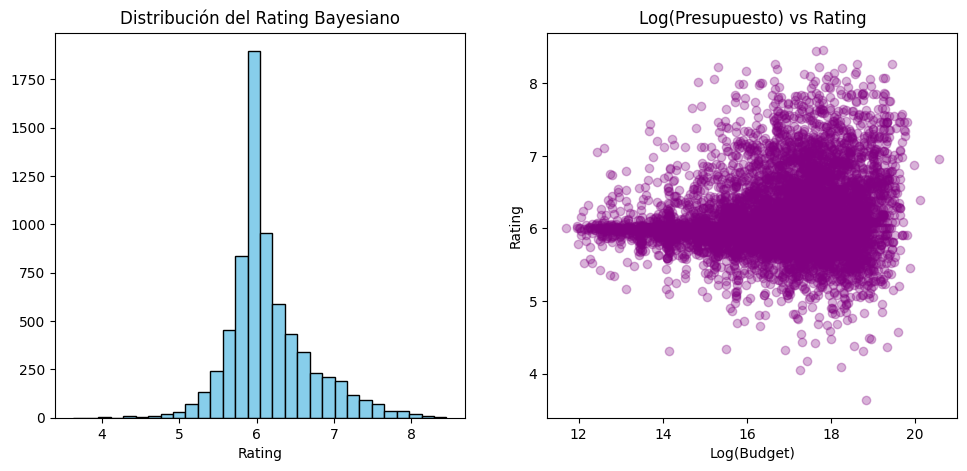

In [8]:
# ANÁLISIS EXPLORATORIO (EDA)

plt.figure(figsize=(18, 5))

# Vemos cómo se distribuye nuestro objetivo (Rating)
plt.subplot(1, 3, 1)
plt.hist(df_filtrado['weighted_rating'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución del Rating Bayesiano')
plt.xlabel('Rating')

# Vemos la relación Presupuesto vs Rating
plt.subplot(1, 3, 2)
# Usamos escala logarítmica en X para ver mejor los datos
plt.scatter(np.log1p(df_filtrado['budget']), df_filtrado['weighted_rating'], alpha=0.3, color='purple')
plt.title('Log(Presupuesto) vs Rating')
plt.xlabel('Log(Budget)')
plt.ylabel('Rating')

In [9]:
# Medida de correlación numérica
print("Correlación entre Presupuesto y Rating:", df_filtrado['budget'].corr(df_filtrado['weighted_rating']))

Correlación entre Presupuesto y Rating: 0.14405314135855538


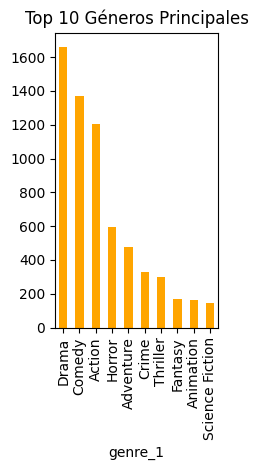

In [10]:
# Vemos los Géneros más frecuentes
plt.subplot(1, 3, 3)
# Contamos el género principal
df_filtrado['genre_1'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Géneros Principales')
plt.xticks()

plt.tight_layout()
plt.show()

### Separación de Datos Estratificada
Dividimos los datos en dos conjuntos:
* **Entrenamiento (Train):** Para enseñar al modelo (80%).
* **Prueba (Test):** Para evaluarlo después (20%).

Usamos `StratifiedShuffleSplit` basado en el presupuesto para asegurar que en ambos grupos haya una proporción equilibrada de películas caras y baratas.

In [11]:
# Creamos categorías de presupuesto para dividir equitativamente
df_filtrado['budget_cat'] = pd.cut(np.log1p(df_filtrado['budget']), bins=5, labels=[1,2,3,4,5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(df_filtrado, df_filtrado['budget_cat']):
    train_set = df_filtrado.iloc[train_idx].copy()
    test_set = df_filtrado.iloc[test_idx].copy()

# Definimos X (Entradas) e y (Objetivo)
features = ['budget', 'director', 'actor_1', 'actor_2', 'actor_3', 'genre_1', 'genre_2', 'genre_3']
target = 'weighted_rating'

X_train = train_set[features]
y_train = train_set[target]
X_test = test_set[features]
y_test = test_set[target]

print(f"Entrenamiento: {X_train.shape}, Test: {X_test.shape}")

Entrenamiento: (5633, 8), Test: (1409, 8)


### Configuración del Pipeline de Preprocesamiento
Preparamos las transformaciones automáticas que sufrirán los datos antes de entrar al modelo:
* **Variables Numéricas (Budget):** Se escalan (StandardScaler) para normalizar los valores.
* **Variables Categóricas (Texto):** Se aplica `OneHotEncoder` para convertirlas en números (0 y 1). Cogemos solo los 10 valores más frecuentes de cada columna para no saturar el modelo.

In [12]:
# Definición de columnas
numeric_cols = ['budget']
categorical_cols = ['director', 'actor_1', 'actor_2', 'actor_3', 'genre_1', 'genre_2', 'genre_3']

# Transformadores

# Para numéricos: Solo escalamos
numeric_transformer = StandardScaler()

# Para categóricos: Usamos OneHotEncoder automático
# max_categories=10 -> Automáticamente coge los 10 top y el resto los llama 'infrequent_sklearn'
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    max_categories=10
)

# Preprocesador (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        # TargetEncoder usa el 'y' (Rating) para codificar 'X' (Director/Actor)
        ('target_enc', ce.TargetEncoder(handle_unknown='value'), categorical_cols),

        # Estandarización de variables numéricas
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough' # Mantiene la columna 'Language' si no fue categorizada antes.
)

# Definición de Modelos
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])

### Definición de Modelos
Creamos dos flujos de trabajo (`Pipelines`) completos:
1.  **Regresión Lineal:** Un modelo simple que busca relaciones directas.
2.  **Random Forest:** un modelo complejo que usa múltiples árboles de decisión para capturar relaciones no lineales.

### Entrenamiento y Evaluación
1.  Entrenamos ambos modelos con los datos de **Train**.
2.  Hacemos predicciones sobre los datos de **Test**.
3.  Calculamos el error (**RMSE**) y la calidad del ajuste (**R2**) para ver cuál funciona mejor.

In [13]:
# Entrenamiento y Resultados

print("\nEntrenando Modelos")

# Regresión Lineal
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# Random Forest
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

# Métricas
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nResultados Regresión Lineal -> RMSE: {rmse_lr:.4f} | R2: {r2_lr:.4f}")
print(f"Resultados Random Forest    -> RMSE: {rmse_rf:.4f} | R2: {r2_rf:.4f}")


Entrenando Modelos

Resultados Regresión Lineal -> RMSE: 0.4822 | R2: 0.1427
Resultados Random Forest    -> RMSE: 0.4918 | R2: 0.1081


### Comparación Visual de Modelos
Generamos gráficos para comparar las predicciones de la Regresión Lineal (Azul) contra las del Random Forest (Verde).
* Cuanto más cerca estén los puntos de la línea roja discontinua, mejor es el modelo.

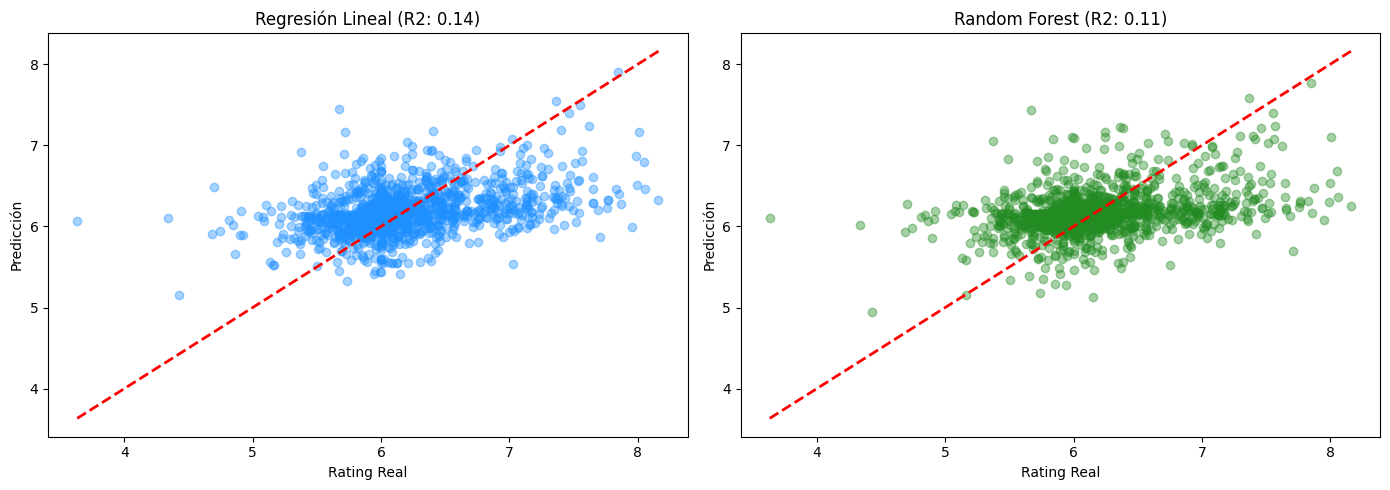

In [14]:
# Gráficos
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Regresión Lineal (R2: {r2_lr:.2f})')
plt.xlabel('Rating Real')
plt.ylabel('Predicción')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Random Forest (R2: {r2_rf:.2f})')
plt.xlabel('Rating Real')
plt.ylabel('Predicción')

plt.tight_layout()
plt.show()

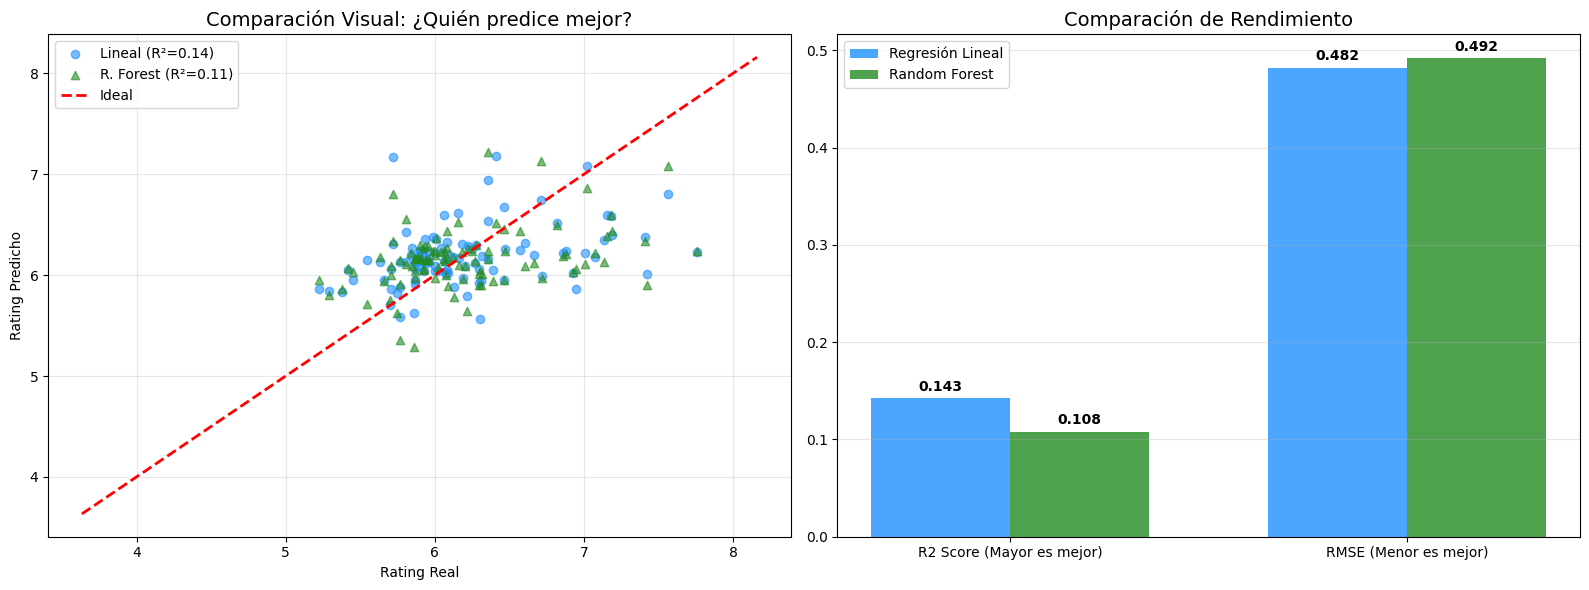

In [15]:
# GRÁFICO DE COMPARACIÓN FINAL (Regresión Lineal vs Random Forest)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 6))

# Comparación Visual de Predicciones (Scatter Overlay)
ax1 = plt.subplot(1, 2, 1)

# Tomamos una muestra aleatoria de 100 puntos para que el gráfico no se vea sucio
indices = np.random.choice(len(y_test), size=min(100, len(y_test)), replace=False)

# Convertimos a array numpy para poder indexar con la lista de índices
y_test_sample = y_test.iloc[indices].values
y_pred_lr_sample = y_pred_lr[indices]
y_pred_rf_sample = y_pred_rf[indices]

# Pintamos Regresión Lineal (Azul)
ax1.scatter(y_test_sample, y_pred_lr_sample, color='dodgerblue', alpha=0.6, marker='o', label=f'Lineal (R²={r2_lr:.2f})')
# Pintamos Random Forest (Verde)
ax1.scatter(y_test_sample, y_pred_rf_sample, color='forestgreen', alpha=0.6, marker='^', label=f'R. Forest (R²={r2_rf:.2f})')

# Línea de Predicción Perfecta
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')

ax1.set_title('Comparación Visual: ¿Quién predice mejor?', fontsize=14)
ax1.set_xlabel('Rating Real')
ax1.set_ylabel('Rating Predicho')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Comparación de Métricas (Barras)
ax2 = plt.subplot(1, 2, 2)

metrics = ['R2 Score (Mayor es mejor)', 'RMSE (Menor es mejor)']
lr_scores = [r2_lr, rmse_lr]
rf_scores = [r2_rf, rmse_rf]

x = np.arange(len(metrics))
width = 0.35

# Barras
rects1 = ax2.bar(x - width/2, lr_scores, width, label='Regresión Lineal', color='dodgerblue', alpha=0.8)
rects2 = ax2.bar(x + width/2, rf_scores, width, label='Random Forest', color='forestgreen', alpha=0.8)

ax2.set_title('Comparación de Rendimiento', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Función para poner el numerito encima de la barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax2.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### Importancia de Variables
Extraemos del **Random Forest** qué variables fueron las más útiles para tomar sus decisiones. Esto nos ayuda a entender qué factores influyen más en el éxito de una película (¿es el presupuesto?, ¿el director?, ¿el género?).

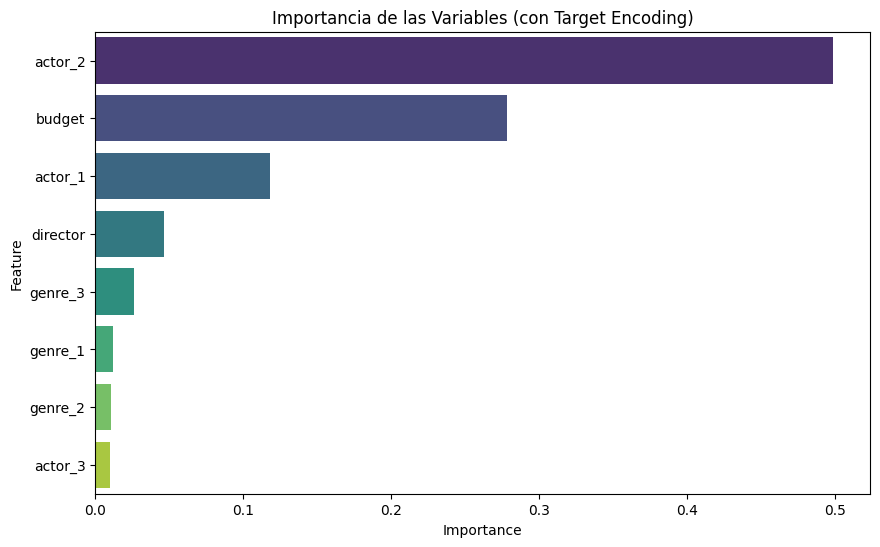


Interpretación:
La variable más importante es: actor_2


In [16]:
# ANÁLISIS DE IMPORTANCIA DE VARIABLES
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Obtenemos el modelo ya entrenado del pipeline
rf_model = rf_pipeline.named_steps['regressor']

# Obtenemos las importancias calculadas por el modelo
importances = rf_model.feature_importances_

# Definimos los nombres de las variables
# Con Target Encoding, las columnas son las mismas que al principio.
# El orden depende de cómo definimos el preprocesador: primero pusimos 'num' (budget) y luego 'cat' (el resto)
feature_names = numeric_cols + categorical_cols

# Creamos el DataFrame para visualizar
feature_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp = feature_imp.sort_values(by='Importance', ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_imp, palette='viridis', legend=False)
plt.title('Importancia de las Variables (con Target Encoding)')
plt.show()

print("\nInterpretación:")
print(f"La variable más importante es: {feature_imp.iloc[0]['Feature']}")

### Conclusiones Finales
Imprimimos un resumen automático interpretando los resultados:
* Decimos qué modelo ganó basándonos en el R2.
* Identificamos la variable más influyente.

In [17]:
# CONCLUSIONES
print("\nCONCLUSIONES")
if r2_rf > r2_lr:
    print(f"El modelo Random Forest (R2={r2_rf:.2f}) superó a la Regresión Lineal (R2={r2_lr:.2f}).")
    print("Esto indica que la relación entre el éxito de una película y sus características NO es lineal.")
else:
    print(f"La Regresión Lineal funcionó mejor o igual, indicando relaciones simples.")

print(f"La variable más influyente fue: {feature_imp.iloc[0]['Feature']}.")
print("El presupuesto (budget) suele ser clave, pero el director y el género matizan el éxito.")


CONCLUSIONES
La Regresión Lineal funcionó mejor o igual, indicando relaciones simples.
La variable más influyente fue: actor_2.
El presupuesto (budget) suele ser clave, pero el director y el género matizan el éxito.
